In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import json
from datetime import date
import os

import seaborn as sns

color_pal = sns.color_palette()

plt.style.use("fivethirtyeight")
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["lines.markersize"] = 4
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 14

In [14]:
def calculate_weights(
    target_y, features_X, base_high_w=10.0, alert_w=50.0, spike_w=200.0
):
    weights = np.ones(len(target_y))
    pollen = target_y.values

    # Tier 1: Low-Medium Levels (>= 10)
    weights[pollen >= 10] = base_high_w

    # Tier 2: Warnings/Alerts (>= 50)
    weights[pollen >= 50] = alert_w

    # Tier 3: "Explosive Spike" (Jump >= 300)
    if "polen_lag_1" in features_X.columns:
        pollen_today = pollen
        pollen_yesterday = features_X["polen_lag_1"].values
        try:
            jump = pollen_today - pollen_yesterday
            explosive_mask = jump >= 300
            weights[explosive_mask] = spike_w
        except:
            pass
    
    weights = np.power(1.5, np.log1p(target_y))
    return weights


In [15]:
def apply_safety_noise(X, tipo, seed=None):
    X_noisy = X.copy()

    NOISE_LEVEL = 0.20
    SAFETY_BIAS = 0.90

    if f"polen_{tipo}" in X_noisy.columns:
        noise = np.random.normal(SAFETY_BIAS, NOISE_LEVEL, size=len(X_noisy))
        X_noisy[f"polen_{tipo}"] = (
            X_noisy[f"polen_{tipo}"] * noise
        )

    return X_noisy

In [16]:
# Creación de los targets
def create_targets(df, tipo):
    df[f"target_t0"] = df[f"polen_{tipo}"]
    df[f"target_t1"] = df[f"polen_{tipo}"].shift(-1)
    df[f"target_t2"] = df[f"polen_{tipo}"].shift(-2)

### Train final models

In [17]:
tipos_polinicos = ["gramineas", "cupresaceas", "olivo", "platano", "urticaceas", "quenopodiaceas"]
targets = [0, 1, 2]
for tipo in tipos_polinicos:
    df = pd.read_csv(f'../my_datasets/datos_{tipo}.csv')
    df["fecha"] = pd.to_datetime(df["fecha"])
    create_targets(df, tipo)
    df.to_csv(f'../my_datasets/datos_{tipo}.csv', index=False)

    for i in targets:
        FEATURES = json.load(open('json/allFeatures.json', 'r', encoding='utf-8'))
        TARGET = f'target_t{i}'

        train_data = df.dropna(subset=[TARGET]).copy()

        X_train = train_data[FEATURES]
        y_train = train_data[TARGET]

        y_train_log = np.log1p(y_train)

        if f"polen_{tipo}" in X_train.columns:
            X_train = X_train.drop(columns=[f"polen_{tipo}"])
        X_train = X_train.drop(columns=X_train.filter(regex=r'^target_t').columns)

        pesos = calculate_weights(y_train, X_train)
        X_train = apply_safety_noise(X_train, tipo, seed=42)

        with open(f"json/{tipo}/optuna_best_params_t{i}.json", "r") as f:
            best_params = json.load(f)

        prelim_reg = xgb.XGBRegressor(
            base_score=0.5, booster="gbtree", objective="reg:squarederror", **best_params
        )
        prelim_reg.fit(X_train, y_train_log)

        importancias = pd.DataFrame(
            {"feature": FEATURES, "importance": prelim_reg.feature_importances_}
        ).sort_values("importance", ascending=False)

        TOP_FEATURES = importancias[importancias["importance"] > 0.002]["feature"].tolist()

        if len(TOP_FEATURES) < 10:
            TOP_FEATURES = importancias.head(10)["feature"].tolist()

        X_train_clean = X_train[TOP_FEATURES]

        with open(f'json/{tipo}/features_t{i}.json', 'w') as f:
            json.dump(TOP_FEATURES, f)


        reg = xgb.XGBRegressor(
            base_score=0.5, booster="gbtree", objective="reg:squarederror", **best_params
        )

        reg.fit(
            X_train_clean,
            y_train_log,
            eval_set=[(X_train_clean, y_train_log)],
            verbose=100,
            sample_weight=pesos,
        )

        reg.get_booster().save_model(f"json/{tipo}/modelo_t{i}.json")

[0]	validation_0-rmse:1.50741
[100]	validation_0-rmse:0.83959
[200]	validation_0-rmse:0.56482
[300]	validation_0-rmse:0.46127
[400]	validation_0-rmse:0.41819
[500]	validation_0-rmse:0.39384
[600]	validation_0-rmse:0.37727
[700]	validation_0-rmse:0.36773
[800]	validation_0-rmse:0.36331
[900]	validation_0-rmse:0.36247
[1000]	validation_0-rmse:0.36200
[1100]	validation_0-rmse:0.36131
[1200]	validation_0-rmse:0.36103
[1300]	validation_0-rmse:0.36061
[1400]	validation_0-rmse:0.36028
[1500]	validation_0-rmse:0.35969
[1600]	validation_0-rmse:0.35924
[1700]	validation_0-rmse:0.35893
[1800]	validation_0-rmse:0.35859
[1900]	validation_0-rmse:0.35851
[1997]	validation_0-rmse:0.35839
[0]	validation_0-rmse:1.40471
[100]	validation_0-rmse:0.36449
[200]	validation_0-rmse:0.36181
[300]	validation_0-rmse:0.36062
[400]	validation_0-rmse:0.35945
[500]	validation_0-rmse:0.35912
[600]	validation_0-rmse:0.35876
[700]	validation_0-rmse:0.35864
[800]	validation_0-rmse:0.35779
[900]	validation_0-rmse:0.35776
[

### Test Models (Temporal Cross Validation)

In [18]:
from sklearn.metrics import mean_absolute_error, r2_score
from matplotlib.lines import Line2D

tipos_polinicos = {
    "gramineas": (400, 10, 50),
    "cupresaceas": (500, 50, 150),
    "olivo": (500, 50, 200),
    "platano": (300, 50, 150),
    "urticaceas": (100, 10, 40),
    "quenopodiaceas": (30, 5, 10)
}

def test_model(tipo, target, anos_validacion):
    resultados_mae = []

    df = pd.read_csv(f'../my_datasets/datos_{tipo}.csv')
    df["fecha"] = pd.to_datetime(df["fecha"])
    create_targets(df, tipo)

    for v_year in anos_validacion:
        print(f"\n--- Evaluando Fold: Entrenando con años < {v_year} | Validando con {v_year} ---")
        TARGET = f'target_t{target}'
        FEATURES = json.load(open('json/allFeatures.json', 'r', encoding='utf-8'))
        
        train_data = df[df['fecha'].dt.year < v_year].copy().dropna(subset=[TARGET])
        test_data = df[df['fecha'].dt.year == v_year].copy().dropna(subset=[TARGET])

        X_train = train_data[FEATURES]
        X_val = test_data[FEATURES]

        columnas_leakage = [c for c in X_train.columns if c.startswith('target_t') or c == f"polen_{tipo}"]

        X_train = X_train.drop(columns=columnas_leakage, errors='ignore')
        X_val = X_val.drop(columns=columnas_leakage, errors='ignore')
        
        y_train = train_data[TARGET]
        y_val = test_data[TARGET]

        pesos = calculate_weights(y_train, X_train)
        X_train = apply_safety_noise(X_train, tipo, seed=42)

        y_train_log = np.log1p(y_train)
        
        # Entrenar modelo
        with open(f"json/{tipo}/optuna_best_params_t{target}.json", "r") as f:
            best_params = json.load(f)
        reg = xgb.XGBRegressor(**best_params)
        reg.fit(X_train, y_train_log, sample_weight=pesos)
        
        # Reversión logaritmos
        preds_log = reg.predict(X_val)
        preds_reales = np.expm1(preds_log)
        y_val_reales = y_val
        
        mae_fold = mean_absolute_error(y_val_reales, preds_reales)
        resultados_mae.append(mae_fold)
        print(f"MAE para el año {v_year}: {mae_fold:.2f} granos")

        test_data = pd.read_csv(f'../my_datasets/datos_{tipo}.csv')
        targetCol = f'target_t{target}'

        #Make predictions
        test_data["fecha"] = pd.to_datetime(test_data["fecha"])
        test_data = test_data[test_data["fecha"].dt.year == v_year].dropna(subset=[targetCol]).copy()

        with open(f'json/{tipo}/features_t{target}.json', 'r') as f:
            TOP_FEATURES = json.load(f)

        reg = xgb.XGBRegressor()
        reg.load_model(f'json/{tipo}/modelo_t{target}.json')

        preds_log = reg.predict(test_data[TOP_FEATURES])
        preds_reales = np.expm1(preds_log)
        test_data[f"prediccion_t{target}"] = preds_reales

        
        #--- VISUALIZACIÓN ---

        test_data_temporada = test_data.copy()

        def obtener_zona(valor):
            if valor < tipos_polinicos[tipo][1]:
                return 0
            elif tipos_polinicos[tipo][1] <= valor <= tipos_polinicos[tipo][2]:
                return 1
            else:
                return 2
            
        test_data_temporada["zona_real"] = test_data_temporada[targetCol].apply(obtener_zona)
        test_data_temporada["zona_pred"] = test_data_temporada[f"prediccion_t{target}"].apply(obtener_zona)

        test_data_temporada["color_punto"] = np.where(
            test_data_temporada["zona_real"] != test_data_temporada["zona_pred"], "red", "blue"
        )

        test_data_temporada["target_visual"] = test_data_temporada[targetCol].clip(upper=tipos_polinicos[tipo][0])
        test_data_temporada["pred_visual"] = test_data_temporada[f"prediccion_t{target}"].clip(upper=tipos_polinicos[tipo][0])

        plt.figure(figsize=(15, 8))
        plt.axhspan(0, tipos_polinicos[tipo][1], color="green", alpha=0.15, label="Bajo (< {tipos_polinicos[tipo][1]})")
        plt.axhspan(tipos_polinicos[tipo][1], tipos_polinicos[tipo][2], color="yellow", alpha=0.15, label="Moderado ({tipos_polinicos[tipo][1]}-{tipos_polinicos[tipo][2]})")
        plt.axhspan(tipos_polinicos[tipo][2], tipos_polinicos[tipo][0], color="red", alpha=0.15, label="Alto (> {tipos_polinicos[tipo][2]})")

        plt.plot(
            test_data_temporada["fecha"],
            test_data_temporada["target_visual"],
            label=f"Real ({tipo})",
            color="blue",
            alpha=0.4,
            linewidth=1,
        )
        plt.plot(
            test_data_temporada["fecha"],
            test_data_temporada["pred_visual"],
            label="Predicción Modelo",
            color="gray",
            linestyle="--",
            alpha=0.4,
            linewidth=1,
        )

        plt.scatter(
            test_data_temporada["fecha"],
            test_data_temporada["pred_visual"],
            c=test_data_temporada["color_punto"],
            s=40,
            zorder=5,
            edgecolor="black",
            linewidth=0.5,
        )

        plt.ylim(0, tipos_polinicos[tipo][0] + 10)
        plt.ylabel("Granos de polen / $m^3$ (Topado a 300)")

        plt.title("Comparativa de Polen: " + tipo.capitalize())
        plt.xlabel("Fecha")
        plt.ylabel("Granos de polen / $m^3$")

        legend_elements = [
            Line2D([0], [0], color="blue", lw=2, label="Dato Real"),
            Line2D([0], [0], color="gray", linestyle="--", label="Tendencia Predicción"),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="Predicción (Zona Correcta)",
                markerfacecolor="blue",
                markersize=8,
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label="Predicción (Zona Incorrecta)",
                markerfacecolor="red",
                markersize=8,
            ),
            plt.Rectangle((0, 0), 1, 1, fc="green", alpha=0.15, label="Zona Verde ($<50$)"),
            plt.Rectangle(
                (0, 0), 1, 1, fc="yellow", alpha=0.15, label="Zona Amarilla ($50-150$)"
            ),
            plt.Rectangle((0, 0), 1, 1, fc="red", alpha=0.15, label="Zona Roja ($>150$)"),
        ]
        plt.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1, 1))

        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        os.makedirs('output', exist_ok=True)
        plt.savefig(rf'output/{tipo}_pred_t+{target}.png', dpi=300, bbox_inches='tight') # Guardar
        plt.show()

        fi = pd.DataFrame(
            data=reg.feature_importances_, index=reg.feature_names_in_, columns=["importance"]
        )
        fi.sort_values("importance", ascending=False).head(25).sort_values("importance").plot(
            kind="barh", title="Top 25 Feature Importance"
        )
        plt.show()

        mae = mean_absolute_error(
            test_data_temporada[targetCol], test_data_temporada[f"prediccion_t{target}"]
        )
        r2 = r2_score(test_data_temporada[targetCol], test_data_temporada[f"prediccion_t{target}"])

        print(f"Error Medio Absoluto (MAE): {mae:.2f} granos")
        print(f"Coeficiente de determinación ($R^2$): {r2:.2f}")
        
    print(f"\n=== MAE Promedio de la Validación Cruzada: {np.mean(resultados_mae):.2f} granos ===")


--- Evaluando Fold: Entrenando con años < 2023 | Validando con 2023 ---
MAE para el año 2023: 23.13 granos


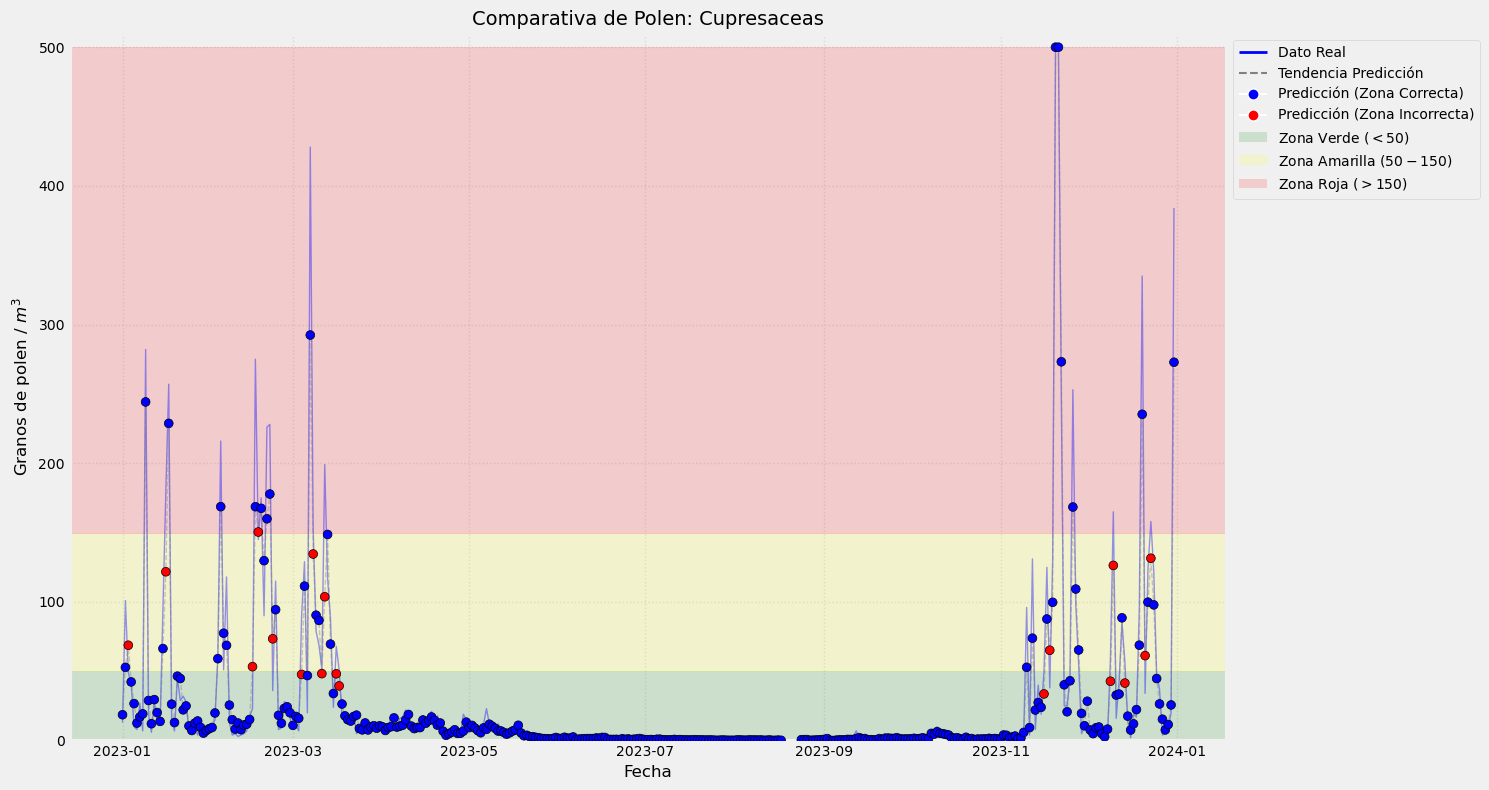

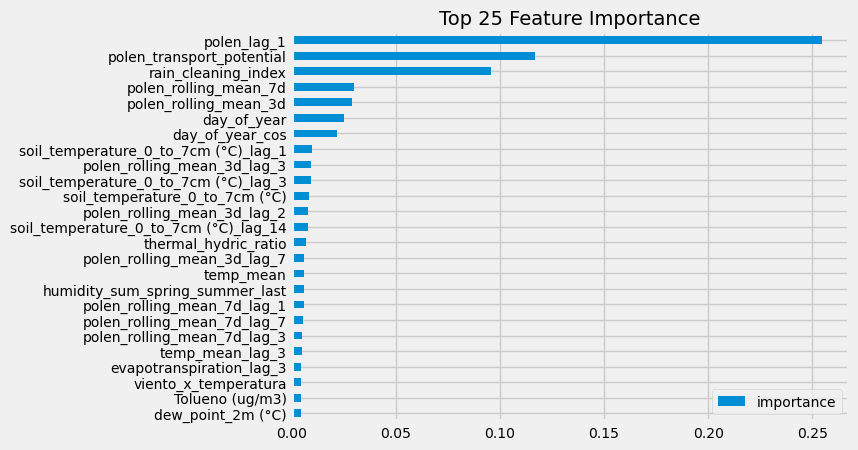

Error Medio Absoluto (MAE): 8.52 granos
Coeficiente de determinación ($R^2$): 0.94

--- Evaluando Fold: Entrenando con años < 2024 | Validando con 2024 ---
MAE para el año 2024: 42.42 granos


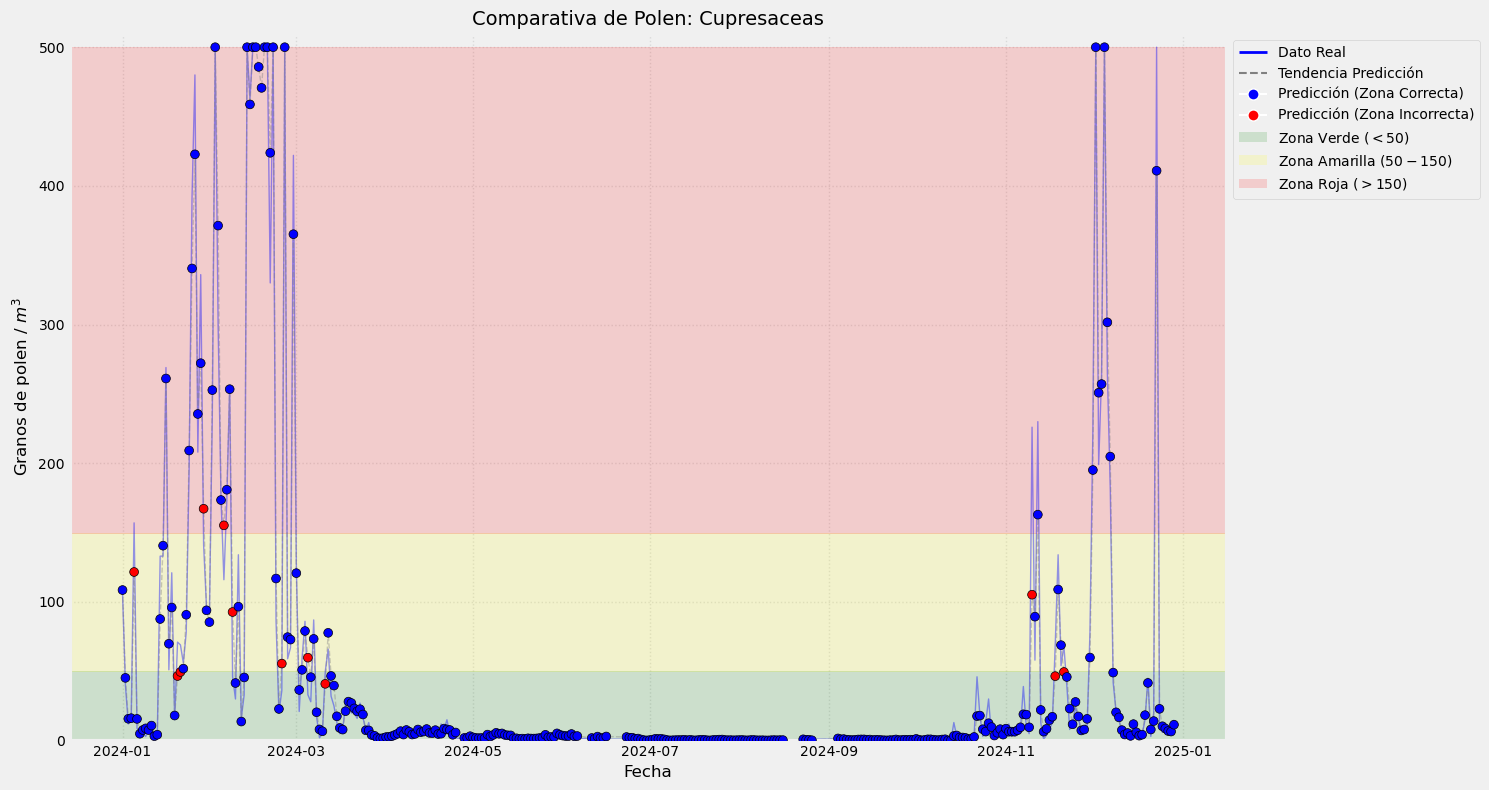

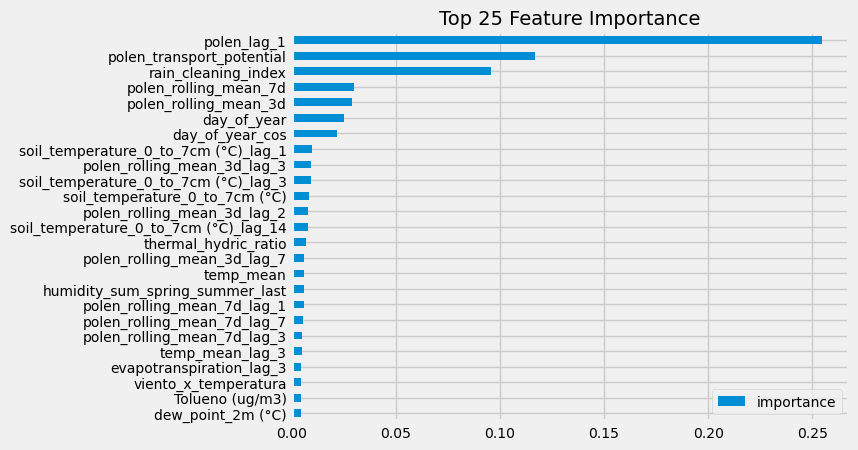

Error Medio Absoluto (MAE): 11.88 granos
Coeficiente de determinación ($R^2$): 0.95

--- Evaluando Fold: Entrenando con años < 2025 | Validando con 2025 ---
MAE para el año 2025: 12.92 granos


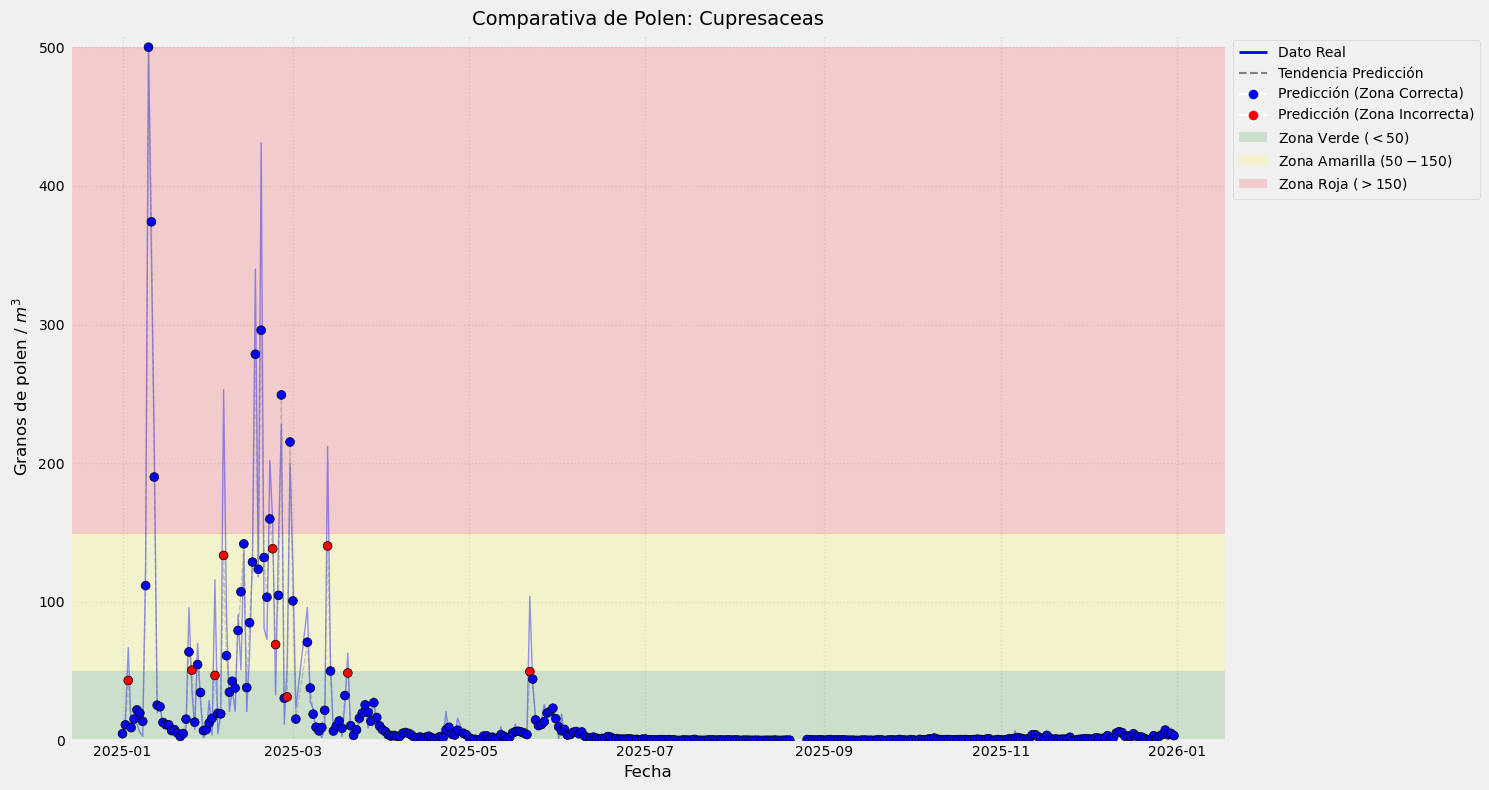

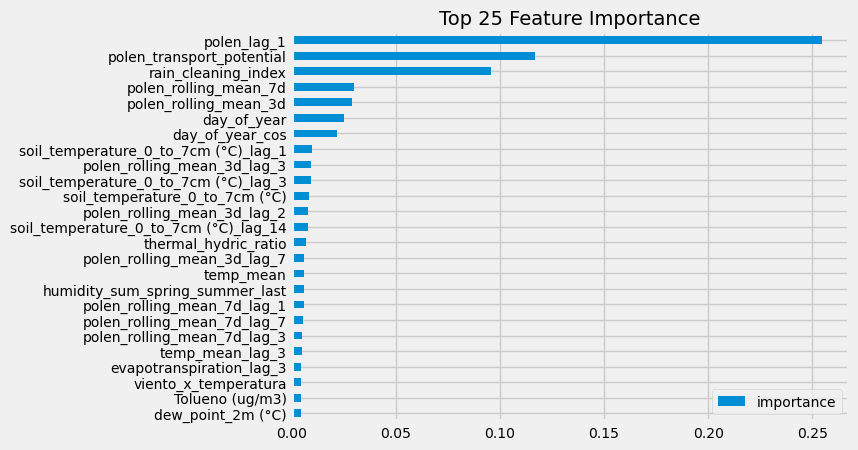

Error Medio Absoluto (MAE): 5.65 granos
Coeficiente de determinación ($R^2$): 0.92

=== MAE Promedio de la Validación Cruzada: 26.16 granos ===


In [19]:
tipos_polinicos = {
    "gramineas": (400, 10, 50),
    "cupresaceas": (500, 50, 150),
    "olivo": (500, 50, 200),
    "platano": (300, 50, 150),
    "urticaceas": (100, 10, 40),
    "quenopodiaceas": (30, 5, 10)
}
test_model('cupresaceas', target = 0, anos_validacion = [2023, 2024, 2025])